In [1]:
import seaborn as sns
import seaborn.objects as so
import pandas as pd

## CS

In [2]:
import pandas as pd
import os

LIST_PATH="../../data/cs_setimes/lexicons/"

def x_to_bool(s):
	return s == "x"

# get rid of warning
pd.set_option('future.no_silent_downcasting', True)

annotations_all = None
for listname in [x for x in os.listdir("../../manual_eval/bcms_setimes") if (x.startswith("list") and x.endswith(".csv"))]:
    annotations = pd.read_csv("../../manual_eval/bcms_setimes/" + listname, header=0)
    annotations = annotations.drop(columns=["score", "selection_freq", "in_blacklist", "feature", "feature2", "note"])
    annotations['list'] = listname
    if annotations_all is None:
        annotations_all = annotations.copy()
    else:
        annotations_all = pd.concat([annotations_all, annotations]).drop_duplicates().reset_index(drop=True)

bl_df = pd.read_csv(LIST_PATH + "filtered_blacklist.txt", sep="\t", names=["token"])
bl_df["in_black"] = True
df_join1 = pd.merge(bl_df, annotations_all, how='right', on=["token"], suffixes=(None, "_b"))

wl_df = pd.read_csv(LIST_PATH + "filtered_whitelist.txt", sep="\t", names=["label", "token"])
wl_df["in_white"] = True
df_join = pd.merge(wl_df, df_join1, how='right', on=["token", "label"], suffixes=(None, "_w"))
df_join['NotShib'] = df_join['shibboleth'].map({'no': True, 'yes': False})
df_join['AnyShib'] = df_join['shibboleth'].map({'yes': True, 'no': False})
df_join = df_join.fillna(False)

results = {}
for label in ("hr", "sr"):
	df_label = df_join[df_join["label"] == label]
	results[label] = {
		"annotated_items": df_label.shape[0],
		"blacklisted": (df_label['in_black']).sum(),
		"whitelisted": (df_label['in_white']).sum(),
		"non_shibboleths": (df_label['NotShib']).sum(),
		"shibboleths": (df_label['AnyShib']).sum(),
		"blacklisted_shib": (df_label['in_black'] & df_label['AnyShib']).sum(),
		"whitelisted_nonshib": (df_label['in_white'] & df_label['NotShib']).sum()
	}

results["all"] = {
	"annotated_items": df_join.shape[0],
	"blacklisted": (df_join['in_black']).sum(),
	"whitelisted": (df_join['in_white']).sum(),
	"non_shibboleths": (df_join['NotShib']).sum(),
	"shibboleths": (df_join['AnyShib']).sum(),
	"blacklisted_shib": (df_join['in_black'] & df_join['AnyShib']).sum(),
	"whitelisted_nonshib": (df_join['in_white'] & df_join['NotShib']).sum()
}

results_df = pd.DataFrame.from_dict(results)
print(results_df)
print()

errors_df = pd.DataFrame()
errors_df["blacklist error rate"] = results_df.loc["blacklisted_shib"] / results_df.loc["blacklisted"]
errors_df["whitelist error rate"] = results_df.loc["whitelisted_nonshib"] / results_df.loc["whitelisted"]
print(errors_df.T)

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_19027/1888119182.py:10: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


                      hr   sr   all
annotated_items      800  800  1600
blacklisted          318  102   420
whitelisted          334  379   713
non_shibboleths      532  267   799
shibboleths          262  512   774
blacklisted_shib     132   54   186
whitelisted_nonshib  226    8   234

                            hr        sr       all
blacklist error rate  0.415094  0.529412  0.442857
whitelist error rate  0.676647  0.021108  0.328191


In [3]:
df_join["blacklisted_shib"] = df_join['in_black'] & df_join['AnyShib']
df_join["blacklisted_nonshib"] = df_join['in_black'] & df_join['NotShib']
df_join["whitelisted_shib"] = df_join['in_white'] & df_join['AnyShib']
df_join["whitelisted_nonshib"] = df_join['in_white'] & df_join['NotShib']
df_list_qual = df_join.groupby('list')[['blacklisted_shib', 'blacklisted_nonshib', 'whitelisted_shib', 'whitelisted_nonshib']].sum()
df_list_qual['unlisted']  = 200 - df_join.groupby('list')[['blacklisted_shib', 'blacklisted_nonshib', 'whitelisted_shib', 'whitelisted_nonshib']].sum().sum(axis=1)
df_list_qual['true_quality'] = df_join.groupby('list')['AnyShib'].sum()
df_list_qual = (df_list_qual / 200).reset_index()
df_list_qual

,list,blacklisted_shib,blacklisted_nonshib,whitelisted_shib,whitelisted_nonshib,unlisted,true_quality
0,list1.csv,0.195,0.250,0.305,0.115,0.135,0.515
1,list2.csv,0.055,0.110,0.165,0.105,0.565,0.315
2,list3.csv,0.205,0.150,0.305,0.170,0.170,0.525
3,list4.csv,0.045,0.080,0.160,0.160,0.555,0.3
4,list5.csv,0.040,0.140,0.155,0.175,0.490,0.39
5,list6.csv,0.215,0.215,0.380,0.115,0.075,0.61
6,list7.csv,0.060,0.120,0.410,0.120,0.290,0.55
7,list8.csv,0.115,0.105,0.515,0.210,0.055,0.665


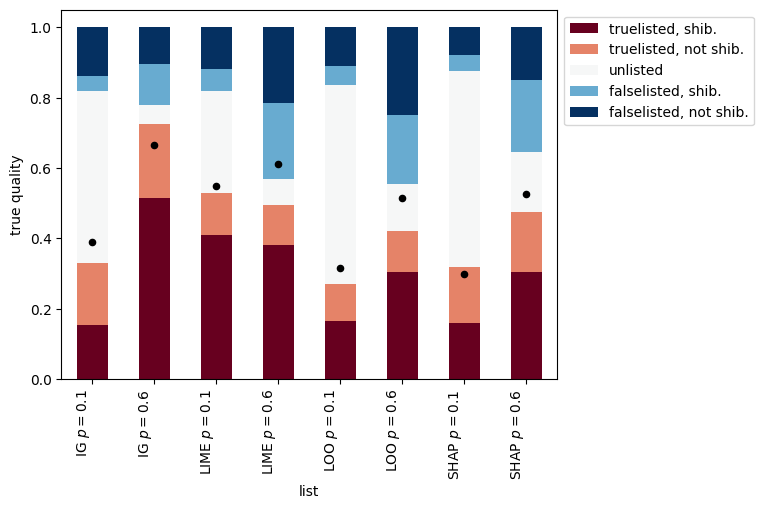

In [4]:
import matplotlib.pyplot as plt
lst_to_name = {
    "list1.csv": "LOO $p=0.6$",
    "list2.csv": "LOO $p=0.1$",
    "list3.csv": "SHAP $p=0.6$",
    "list4.csv": "SHAP $p=0.1$",
    "list5.csv": "IG $p=0.1$",
    "list6.csv": "LIME $p=0.6$",
    "list7.csv": "LIME $p=0.1$",
    "list8.csv": "IG $p=0.6$",
}
df_list_qual['list'] = df_list_qual['list'].map(lst_to_name)
df_list_qual = df_list_qual.sort_values('list').rename(columns={
    'blacklisted_nonshib': 'falselisted, not shib.',
    'blacklisted_shib': 'falselisted, shib.',
    'whitelisted_nonshib': 'truelisted, not shib.',
    'whitelisted_shib': 'truelisted, shib.',
    'true_quality': 'true quality',
})
ax = df_list_qual[[
    'list', 
    'falselisted, not shib.', 
    'falselisted, shib.', 
    'unlisted', 
    'truelisted, not shib.', 
    'truelisted, shib.'][::-1]
].plot(kind='bar', x='list', stacked=True, colormap='RdBu')
df_list_qual[['true quality', 'list']].plot(kind='scatter', y='true quality', x='list', ax=ax, color='black', marker='o')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=90, ha='right')
ax.get_figure().savefig('CS-reflist-quality.pdf', bbox_inches='tight')

In [5]:
LIST_PATH="../../data/estonian_voro/"

def x_to_bool(s):
	return s == "x"

# get rid of warning
pd.set_option('future.no_silent_downcasting', True)

annotations_all = None
for listname in [x for x in os.listdir("../../manual_eval/eesti-voro/") if x.startswith("estonian_voro.list")]:
	annotations = pd.read_csv("../../manual_eval/eesti-voro/" + listname, sep="\t", header=0)
	annotations['list'] = listname
	if annotations_all is None:
		annotations_all = annotations.copy()
	else:
		annotations_all = pd.concat([annotations_all, annotations]).drop_duplicates().reset_index(drop=True)

annotations_all["Unk"] = False
annotations_all.loc[(annotations_all['Unknown'].str.contains('x', na=False) | annotations_all['Other'].str.contains('x', na=False)), "Unk"] = True
annotations_all["NotShib"] = False
annotations_all.loc[((annotations_all["Unk"] == False) & annotations_all['Unmarked'].str.contains('x', na=False)), "NotShib"] = True
annotations_all["AnyShib"] = False
annotations_all.loc[((annotations_all["Unk"] == False) & (annotations_all["NotShib"] == False) & (annotations_all['Lexicon'].str.contains('x', na=False) | annotations_all['Phon-Morph-infl-Morph-der-Spelling'].str.contains(r'x|s', na=False))), "AnyShib"] = True
annotations_all = annotations_all.drop(columns=["base form", "cognate", "Phon-Morph-infl-Morph-der-Spelling", "Lexicon", "NE", "Other", "Unmarked", "Unknown", "Comment"])

bl_df = pd.read_csv(LIST_PATH + "filtered_blacklist.txt", sep="\t", names=["token"])
bl_df["in_black"] = True
df_join1 = pd.merge(bl_df, annotations_all, how='right', on=["token"], suffixes=(None, "_b"))

wl_df = pd.read_csv(LIST_PATH + "filtered_whitelist.txt", sep="\t", names=["label", "token"])
wl_df["in_white"] = True
df_join = pd.merge(wl_df, df_join1, how='right', on=["token", "label"], suffixes=(None, "_w"))
df_join = df_join.fillna(False)

results = {}
for label in ("est", "vro"):
	df_label = df_join[df_join["label"] == label]
	results[label] = {
		"annotated_items": df_label.shape[0],
		"blacklisted": (df_label['in_black']).sum(),
		"whitelisted": (df_label['in_white']).sum(),
		"non_shibboleths": (df_label['NotShib']).sum(),
		"shibboleths": (df_label['AnyShib']).sum(),
		"blacklisted_shib": (df_label['in_black'] & df_label['AnyShib']).sum(),
		"whitelisted_nonshib": (df_label['in_white'] & df_label['NotShib']).sum()
	}

results["all"] = {
	"annotated_items": df_join.shape[0],
	"blacklisted": (df_join['in_black']).sum(),
	"whitelisted": (df_join['in_white']).sum(),
	"non_shibboleths": (df_join['NotShib']).sum(),
	"shibboleths": (df_join['AnyShib']).sum(),
	"blacklisted_shib": (df_join['in_black'] & df_join['AnyShib']).sum(),
	"whitelisted_nonshib": (df_join['in_white'] & df_join['NotShib']).sum()
}

results_df = pd.DataFrame.from_dict(results)
print(results_df)
print()

errors_df = pd.DataFrame()
errors_df["blacklist error rate"] = results_df.loc["blacklisted_shib"] / results_df.loc["blacklisted"]
errors_df["whitelist error rate"] = results_df.loc["whitelisted_nonshib"] / results_df.loc["whitelisted"]
print(errors_df.T)

                     est  vro   all
annotated_items      800  800  1600
blacklisted           90  115   205
whitelisted          471  384   855
non_shibboleths       64   77   141
shibboleths          721  702  1423
blacklisted_shib      47   51    98
whitelisted_nonshib   15   11    26

                           est       vro       all
blacklist error rate  0.522222  0.443478  0.478049
whitelist error rate  0.031847  0.028646  0.030409


/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_19027/2257812505.py:7: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [6]:
df_join["blacklisted_shib"] = df_join['in_black'] & df_join['AnyShib']
df_join["blacklisted_nonshib"] = df_join['in_black'] & df_join['NotShib']
df_join["whitelisted_shib"] = df_join['in_white'] & df_join['AnyShib']
df_join["whitelisted_nonshib"] = df_join['in_white'] & df_join['NotShib']
df_list_qual = df_join.groupby('list')[['blacklisted_shib', 'blacklisted_nonshib', 'whitelisted_shib', 'whitelisted_nonshib']].sum()
df_list_qual['unlisted']  = 200 - df_join.groupby('list')[['blacklisted_shib', 'blacklisted_nonshib', 'whitelisted_shib', 'whitelisted_nonshib']].sum().sum(axis=1)
df_list_qual['true_quality'] = df_join.groupby('list')['AnyShib'].sum()
df_list_qual = (df_list_qual / 200).reset_index()
df_list_qual

,list,blacklisted_shib,blacklisted_nonshib,whitelisted_shib,whitelisted_nonshib,unlisted,true_quality
0,estonian_voro.list.1.commented_annoteerd.txt,0.140,0.065,0.685,0.010,0.100,0.910
1,estonian_voro.list.2.commented_annoteerd.txt,0.000,0.015,0.265,0.000,0.720,0.930
2,estonian_voro.list.3.commented_annoteerd.txt,0.005,0.010,0.405,0.025,0.555,0.925
3,estonian_voro.list.4.commented_annoteerd.txt,0.110,0.090,0.705,0.030,0.065,0.875
4,estonian_voro.list.5.commented_annoteerd.txt,0.000,0.010,0.460,0.010,0.520,0.950
5,estonian_voro.list.6.commented_annoteerd.txt,0.140,0.165,0.570,0.025,0.100,0.795
6,estonian_voro.list.7.commented_annoteerd.txt,0.090,0.165,0.625,0.030,0.090,0.785
7,estonian_voro.list.8.commented_annoteerd.txt,0.005,0.005,0.420,0.000,0.570,0.945


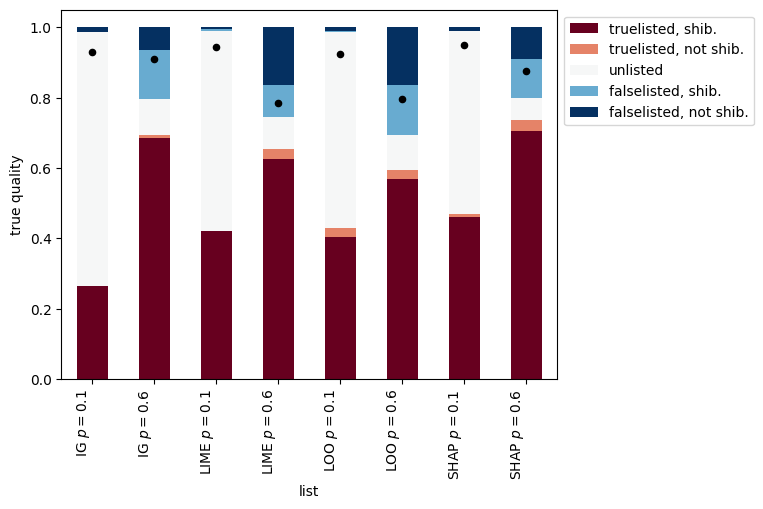

In [7]:
import matplotlib.pyplot as plt
lst_to_name = {
    "estonian_voro.list.1.commented_annoteerd.txt": "IG $p=0.6$",
    "estonian_voro.list.2.commented_annoteerd.txt": "IG $p=0.1$",
    "estonian_voro.list.3.commented_annoteerd.txt": "LOO $p=0.1$",
    "estonian_voro.list.4.commented_annoteerd.txt": "SHAP $p=0.6$",
    "estonian_voro.list.5.commented_annoteerd.txt": "SHAP $p=0.1$",
    "estonian_voro.list.6.commented_annoteerd.txt": "LOO $p=0.6$",
    "estonian_voro.list.7.commented_annoteerd.txt": "LIME $p=0.6$",
    "estonian_voro.list.8.commented_annoteerd.txt": "LIME $p=0.1$",
}
df_list_qual['list'] = df_list_qual['list'].map(lst_to_name)
df_list_qual = df_list_qual.sort_values('list').rename(columns={
    'blacklisted_nonshib': 'falselisted, not shib.',
    'blacklisted_shib': 'falselisted, shib.',
    'whitelisted_nonshib': 'truelisted, not shib.',
    'whitelisted_shib': 'truelisted, shib.',
    'true_quality': 'true quality',
})
ax = df_list_qual[[
    'list', 
    'falselisted, not shib.', 
    'falselisted, shib.', 
    'unlisted', 
    'truelisted, not shib.', 
    'truelisted, shib.'][::-1]
].plot(kind='bar', x='list', stacked=True, colormap='RdBu')
df_list_qual[['true quality', 'list']].plot(kind='scatter', y='true quality', x='list', ax=ax, color='black', marker='o')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=90, ha='right')
ax.get_figure().savefig('EV-reflist-quality.pdf', bbox_inches='tight')

## Scandinavian

In [8]:
LIST_PATH="../../data/scandinavian/"

def x_to_bool(s):
	return s == "x"

# get rid of warning
pd.set_option('future.no_silent_downcasting', True)

annotations_all = None
for listname in [x for x in os.listdir("../../manual_eval/scandinavian/") if x.startswith("scandinavian.annotated.")]:
    annotations = pd.read_csv("../../manual_eval/scandinavian/" + listname)
    annotations['list'] = listname
    if annotations_all is None:
        annotations_all = annotations.copy()
    else:
        annotations_all = pd.concat([annotations_all, annotations]).drop_duplicates().reset_index(drop=True)


annotations_all["AnyShib"] = annotations_all["LexShib"] | annotations_all["NonLexShib"] 

bl_df = pd.read_csv(LIST_PATH + "filtered_blacklist.txt", sep="\t", names=["token"])
bl_df["in_black"] = True
df_join1 = pd.merge(bl_df, annotations_all, how='right', on=["token"], suffixes=(None, "_b"))

wl_df = pd.read_csv(LIST_PATH + "filtered_whitelist.txt", sep="\t", names=["label", "token"])
wl_df["in_white"] = True
df_join = pd.merge(wl_df, df_join1, how='right', on=["token", "label"], suffixes=(None, "_w"))
df_join = df_join.fillna(False)
df_join

/var/folders/dk/_t9z1jr57pq2r38kv2v2dhh40000gp/T/ipykernel_19027/958699039.py:7: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


,label,token,in_white,in_black,id,score,selection_freq,in_blacklist,cognate_da,cognate_nb,...,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,list,AnyShib
0,da,ydmyghed,True,False,0,1.008674,0.10,False,False,ydmykhet,...,False,True,True,False,False,False,False,True,scandinavian.annotated.3.csv,True
1,da,styrtregnede,False,False,1,1.000334,0.10,False,False,styrtregnet,...,False,True,False,False,False,False,False,True,scandinavian.annotated.3.csv,True
2,da,broderede,False,False,2,1.000113,0.10,False,False,broderte,...,False,True,False,False,False,False,False,True,scandinavian.annotated.3.csv,True
3,da,åbningsudsalg,False,False,3,0.999946,0.10,False,False,åpningssalg?,...,False,False,False,False,False,True,False,False,scandinavian.annotated.3.csv,True
4,da,orddelingsfejl,False,False,4,0.999925,0.10,False,False,orddelingsfeil,...,False,False,True,False,False,False,False,True,scandinavian.annotated.3.csv,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,sv,lämnade,True,False,395,0.155722,0.98,False,efterlod,etterlot,...,False,False,False,False,False,True,False,False,scandinavian.annotated.8.csv,True
3196,sv,färdiga,True,False,396,0.154972,0.75,False,False,ferdige,...,False,False,True,False,False,False,False,True,scandinavian.annotated.8.csv,True
3197,sv,väntar,True,False,397,0.154830,1.00,False,venter,venter,...,False,True,True,False,False,False,False,True,scandinavian.annotated.8.csv,True
3198,sv,förändras,True,False,398,0.154672,0.77,False,False,forandre,...,False,True,True,False,False,False,False,True,scandinavian.annotated.8.csv,True


In [9]:
df_join["blacklisted_shib"] = df_join['in_black'] & df_join['AnyShib']
df_join["blacklisted_nonshib"] = df_join['in_black'] & df_join['NotShib']
df_join["whitelisted_shib"] = df_join['in_white'] & df_join['AnyShib']
df_join["whitelisted_nonshib"] = df_join['in_white'] & df_join['NotShib']
df_list_qual = df_join.groupby('list')[['blacklisted_shib', 'blacklisted_nonshib', 'whitelisted_shib', 'whitelisted_nonshib']].sum()
df_list_qual['unlisted']  = 400 - df_join.groupby('list')[['blacklisted_shib', 'blacklisted_nonshib', 'whitelisted_shib', 'whitelisted_nonshib']].sum().sum(axis=1)
df_list_qual['true_quality'] = df_join.groupby('list')['AnyShib'].sum()
df_list_qual = (df_list_qual / 400).reset_index()
df_list_qual

,list,blacklisted_shib,blacklisted_nonshib,whitelisted_shib,whitelisted_nonshib,unlisted,true_quality
0,scandinavian.annotated.1.csv,0.0075,0.0875,0.3900,0.0325,0.4825,0.7350
1,scandinavian.annotated.2.csv,0.0050,0.0750,0.3825,0.0100,0.5275,0.7550
2,scandinavian.annotated.3.csv,0.0100,0.0575,0.4100,0.0175,0.5050,0.7925
3,scandinavian.annotated.4.csv,0.0425,0.2525,0.6350,0.0375,0.0325,0.7100
4,scandinavian.annotated.5.csv,0.0025,0.1075,0.4025,0.0300,0.4575,0.7250
5,scandinavian.annotated.6.csv,0.0350,0.3100,0.5800,0.0275,0.0475,0.6550
6,scandinavian.annotated.7.csv,0.0425,0.2750,0.5950,0.0275,0.0600,0.6900
7,scandinavian.annotated.8.csv,0.0550,0.2825,0.5875,0.0300,0.0450,0.6800


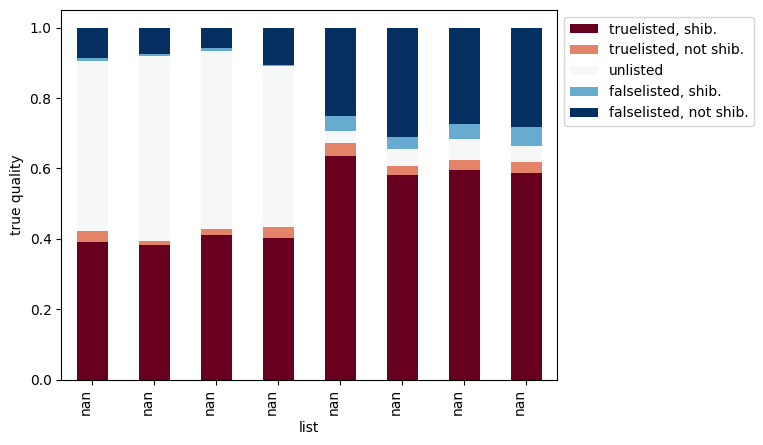

In [11]:
import matplotlib.pyplot as plt
lst_to_name = {
    "scandinavian.annotated.1.csv": "IG $p=0.1$",
    "scandinavian.annotated.2.csv": "IG $p=0.1$",
    "scandinavian.annotated.3.csv": "IG $p=0.1$",
    "scandinavian.annotated.4.csv": "IG $p=0.6$",
    "scandinavian.annotated.5.csv": "IG $p=0.1$",
    "scandinavian.annotated.6.csv": "IG $p=0.6$",
    "scandinavian.annotated.7.csv": "IG $p=0.6$",
    "scandinavian.annotated.8.csv": "IG $p=0.6$",
}
df_list_qual['list'] = df_list_qual['list'].map(lst_to_name)
df_list_qual = df_list_qual.sort_values('list').rename(columns={
    'blacklisted_nonshib': 'falselisted, not shib.',
    'blacklisted_shib': 'falselisted, shib.',
    'whitelisted_nonshib': 'truelisted, not shib.',
    'whitelisted_shib': 'truelisted, shib.',
    'true_quality': 'true quality',
})
ax = df_list_qual[[
    'list', 
    'falselisted, not shib.', 
    'falselisted, shib.', 
    'unlisted', 
    'truelisted, not shib.', 
    'truelisted, shib.'][::-1]
].plot(kind='bar', x='list', stacked=True, colormap='RdBu')
df_list_qual[['true quality', 'list']].plot(kind='scatter', y='true quality', x='list', ax=ax, color='black', marker='o')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=90, ha='right')
ax.get_figure().savefig('Scandi-reflist-quality.pdf', bbox_inches='tight')